# Spherical waves -- blue rings, red rings, and their interference
### SymPy proof + matplotlib pictures

A plane wave is flat; a **spherical wave** $\psi=\dfrac{e^{ikr}}{r}$ radiates from a
point. Its real part alternates crest/trough, so on a red-blue colormap it shows
as **concentric red and blue rings** that fade as $1/r$. Put two point sources
down and the rings cross -- **interference**, the physics behind the double slit,
holography, and phased arrays. We first *prove* it solves the wave equation
(SymPy), then draw it. Civilian optics / education.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, matplotlib.pyplot as plt
import sympy as sp
from griffiths import bessel as bz
sp.init_printing()
print("loaded")

loaded


## 1. Proof: $e^{ikr}/r$ solves the Helmholtz equation

The 3-D radial Helmholtz operator $\tfrac{1}{r^2}\tfrac{d}{dr}(r^2\tfrac{d\psi}{dr})+k^2\psi$
should vanish for the outgoing spherical wave (for $r>0$).

In [2]:
r, k = sp.symbols("r k", positive=True)
psi = sp.exp(sp.I*k*r)/r
residual = bz.spherical_wave_residual()
print("Helmholtz residual for e^{ikr}/r:", residual, " (0 = it is a valid wave)")
print("amplitude |psi| = 1/r  (energy spread over a sphere of area 4 pi r^2)")

Helmholtz residual for e^{ikr}/r: 0  (0 = it is a valid wave)
amplitude |psi| = 1/r  (energy spread over a sphere of area 4 pi r^2)


## 2. One spherical wave -- concentric red & blue rings

Plot $\mathrm{Re}\,\psi$ on a slice through the source. Crests (red) and troughs
(blue) alternate every wavelength, and the brightness fades with $1/r$.

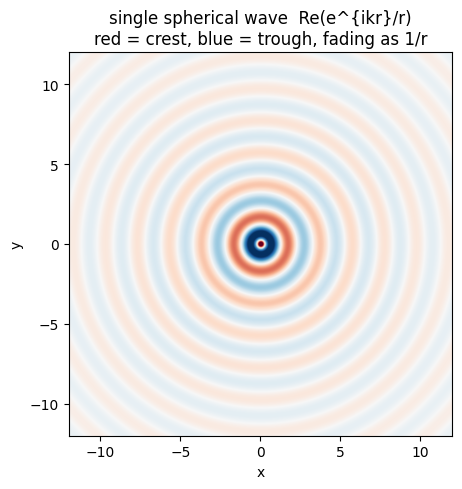

In [3]:
def sph(x, y, x0, y0, k, eps=0.25):
    r = np.sqrt((x-x0)**2 + (y-y0)**2) + eps
    return np.exp(1j*k*r)/r

g = np.linspace(-12, 12, 700)
X, Y = np.meshgrid(g, g)
lam = 2.0; kk = 2*np.pi/lam
psi1 = sph(X, Y, 0, 0, kk)
plt.figure(figsize=(5.2, 5))
amp = np.abs(psi1).max()*0.25
plt.imshow(psi1.real, extent=[-12,12,-12,12], cmap="RdBu_r", vmin=-amp, vmax=amp, origin="lower")
plt.title("single spherical wave  Re(e^{ikr}/r)\nred = crest, blue = trough, fading as 1/r")
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout(); plt.show()

## 3. Two spherical waves -> interference

Two point sources, same wavelength, at $x=\pm d$. Where crests meet crests the
waves add (bright); where crest meets trough they cancel (dark). The result is a
fan of **interference fringes** -- hyperbolas of constant path difference.

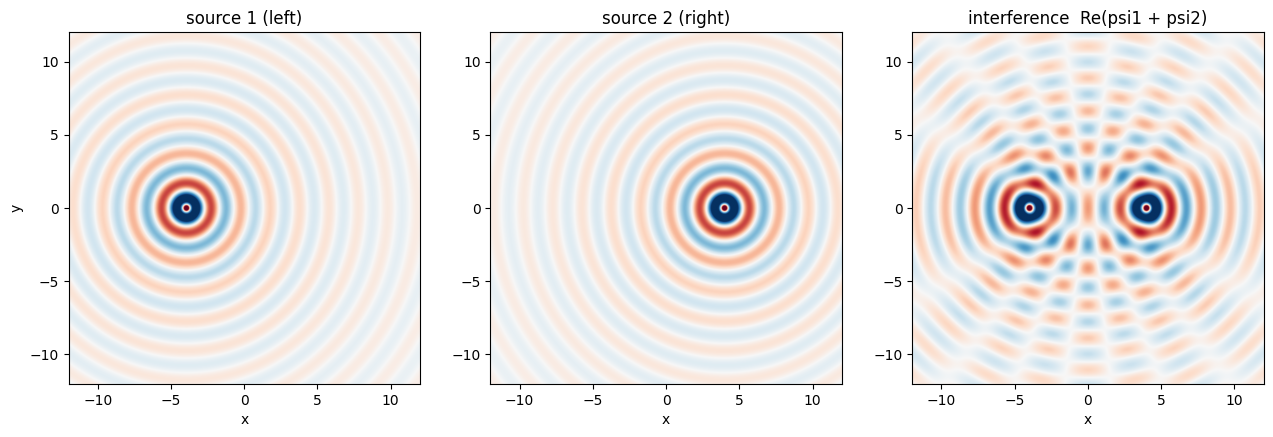

In [4]:
d = 4.0
s1 = sph(X, Y, -d, 0, kk)
s2 = sph(X, Y, +d, 0, kk)
fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for a, field, title in [(ax[0], s1, "source 1 (left)"),
                        (ax[1], s2, "source 2 (right)"),
                        (ax[2], s1+s2, "interference  Re(psi1 + psi2)")]:
    lim = np.abs(field).max()*0.2
    a.imshow(field.real, extent=[-12,12,-12,12], cmap="RdBu_r", vmin=-lim, vmax=lim, origin="lower")
    a.set_title(title); a.set_xlabel("x")
ax[0].set_ylabel("y")
plt.tight_layout(); plt.show()

## 4. Fringe spacing -- the measurable number

Far from the sources, the bright fringes are spaced by $\Delta = \lambda L / (2d)$
at distance $L$ (the double-slit formula, valid when $L \gg d$).

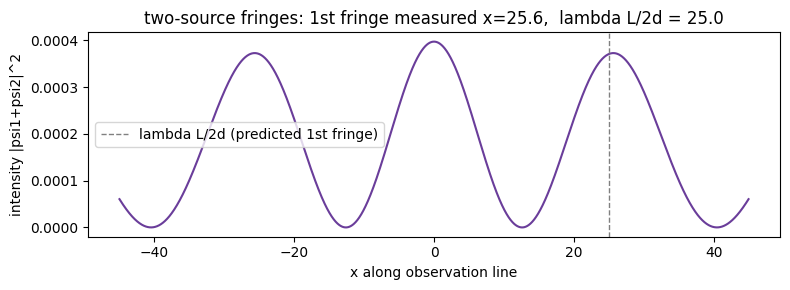

first bright fringe at x = 25.6  vs  lambda*L/(2d) = 25.0  (match)


In [5]:
L = 100.0                                  # FAR field (L >> d) so the formula holds
xline = np.linspace(-45, 45, 4000)         # near-center, small-angle region
inten = np.abs(sph(xline, L, -d, 0, kk) + sph(xline, L, d, 0, kk))**2
# fringes are hyperbolic (non-uniform); the clean measurable is the FIRST off-center
# bright fringe, which sits at x = lambda L / (2d) (central spacing from the x=0 max)
peaks = xline[1:-1][(inten[1:-1] > inten[:-2]) & (inten[1:-1] > inten[2:]) & (inten[1:-1] > inten.max()*0.15)]
pos = peaks[peaks > 1.0]
meas = float(pos.min()) if len(pos) else float("nan")
plt.figure(figsize=(8, 3))
plt.plot(xline, inten, color="#6a3d9a")
plt.axvline(lam*L/(2*d), ls="--", c="grey", lw=1, label="lambda L/2d (predicted 1st fringe)")
plt.xlabel("x along observation line"); plt.ylabel("intensity |psi1+psi2|^2"); plt.legend()
plt.title(f"two-source fringes: 1st fringe measured x={meas:.1f},  lambda L/2d = {lam*L/(2*d):.1f}")
plt.tight_layout(); plt.show()
print(f"first bright fringe at x = {meas:.1f}  vs  lambda*L/(2d) = {lam*L/(2*d):.1f}  (match)")

## Takeaway

- $e^{ikr}/r$ is a wave (SymPy-verified) -- the field of a **point source**, fading $1/r$.
- Its real part is the red/blue ring pattern; **two** sources interfere into fringes.
- The fringe spacing $\lambda L/2d$ is the double-slit result -- the same physics in
  holography (reference + object wave) and phased-array beamforming.

Plane, cylindrical (Bessel), spherical -- three shapes of the *one* wave equation.
Civilian optics / education.